In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Importar las bibliotecas necesarias
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

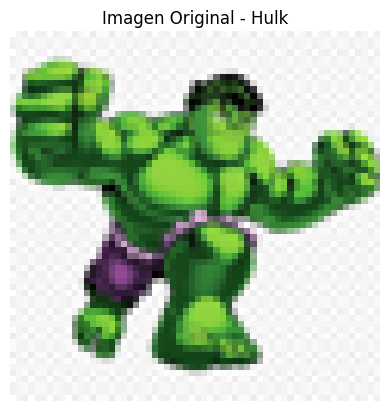

Archivo Excel de valores RGB creado: Hulk_RGB_Matrix.xlsx
Archivo Excel con imagen en pixeles creado: Hulk_Pixel_Image.xlsx


In [4]:
# ================================
# PROYECTO: MATRIZ RGB DE UNA IMAGEN
# Autor: Nicolas Duque
# ================================

# 1. Importar librerías
from PIL import Image
import pandas as pd
import openpyxl
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt

# 2. Cargar la imagen
image_path = "/content/drive/MyDrive/Semestre 8/info_gerencial/hulk.png"   # subir la imagen de Hulk a Colab

img = Image.open(image_path)
img = img.convert("RGB")

# Reducimos tamaño para que Excel no sea gigante
img = img.resize((60,60))

# Mostrar imagen
plt.imshow(img)
plt.axis("off")
plt.title("Imagen Original - Hulk")
plt.show()

# 3. Obtener datos RGB
pixels = list(img.getdata())

width, height = img.size

# Crear matriz RGB
rgb_matrix = []

for y in range(height):
    row = []
    for x in range(width):
        r,g,b = pixels[y*width + x]
        row.append(f"({r},{g},{b})")
    rgb_matrix.append(row)

# 4. Guardar matriz RGB en Excel
df = pd.DataFrame(rgb_matrix)

excel_rgb = "Hulk_RGB_Matrix.xlsx"
df.to_excel(excel_rgb, index=False)

print("Archivo Excel de valores RGB creado:", excel_rgb)


# 5. Crear Excel que RECONSTRUYE la imagen con colores
wb = openpyxl.Workbook()
ws = wb.active

for y in range(height):
    for x in range(width):

        r,g,b = pixels[y*width + x]

        hex_color = f"{r:02x}{g:02x}{b:02x}"

        cell = ws.cell(row=y+1, column=x+1)
        cell.value = ""

        cell.fill = PatternFill(
            start_color=hex_color,
            end_color=hex_color,
            fill_type="solid"
        )

# Ajustar tamaño de celdas
for i in range(1,width+1):
    ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = 2

for i in range(1,height+1):
    ws.row_dimensions[i].height = 12

excel_pixel = "Hulk_Pixel_Image.xlsx"

wb.save(excel_pixel)

print("Archivo Excel con imagen en pixeles creado:", excel_pixel)

In [5]:
from google.colab import files

files.download("Hulk_RGB_Matrix.xlsx")
files.download("Hulk_Pixel_Image.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>